<h1 style="color:darkblue; font-size:36px;">Chewing on Change</h1>
<h2 style="color:gray; font-size:24px;">Lesson 4: Using machine learning models to assess variation in fossilized horse teeth for species classification</h2>

In [4]:
# !pip install torchvision  # Uncomment if torchvision is not installed

In [5]:
# !pip install opencv-python # Uncomment and run if needed

In [15]:
# !pip install scikit-learn

In [22]:
# !pip install matplotlib

In [25]:
# !pip install seaborn

# Our model setup:
We are going to build a model by training it on 55 teeth per class (species) and using 5 unseen teeth per class (species) to test the model's accuracy. 

Run the following code. Record your observations using the student worksheet.

In [1]:
# This first bit of code imports the libraries and packages (bundle of different libraries) needed to perform the analysis. 
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# Set the device to CPU
device = torch.device("cpu")

In [3]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Force 1 channel
    transforms.ToTensor()
])

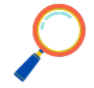 
## Try it Out: Load Image Datasets

In [4]:
# Testing new code for cell below

# Load Image Datasets

import os
import random
from PIL import Image, ImageFilter

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

# ---------------------------
# Paths & class names
# ---------------------------
base_dir = "Image_Folder"
classes = ["D_interpolatus", "E_simplicidens", "Mesohippus_sp", "N_aztecus", "P_leonensis", "S_sandrae"]

# Train/Val folders (ONLY use *_resized_gray for model training)
train_val_dirs = [os.path.join(base_dir, f"{cls}_resized_gray") for cls in classes]
# Test folders
test_dirs = [os.path.join(base_dir, f"{cls}_test") for cls in classes]

# ---------------------------
# Custom transform: blur borders
# ---------------------------
class RandomBlurBorders:
    """
    Randomly blur a border band around the image to reduce background reliance.
    - edge_ratio: fraction of H/W used as border width (e.g., 0.12 = 12%)
    - p: probability to apply
    - radius: Gaussian blur radius
    Works on PIL.Image; apply before ToTensor().
    """
    def __init__(self, edge_ratio=0.12, p=0.7, radius=3):
        self.edge_ratio = edge_ratio
        self.p = p
        self.radius = radius

    def __call__(self, img: Image.Image) -> Image.Image:
        # Operates on grayscale PIL Image ideally
        if random.random() > self.p:
            return img

        if img.mode != 'L':
            img = img.convert('L')

        w, h = img.size
        ew, eh = int(w * self.edge_ratio), int(h * self.edge_ratio)
        blurred = img.filter(ImageFilter.GaussianBlur(self.radius))
        out = img.copy()

        # Paste blurred strips on borders
        # top/bottom
        out.paste(blurred.crop((0, 0, w, eh)), (0, 0))
        out.paste(blurred.crop((0, h - eh, w, h)), (0, h - eh))
        # left/right
        out.paste(blurred.crop((0, 0, ew, h)), (0, 0))
        out.paste(blurred.crop((w - ew, 0, w, h)), (w - ew, 0))

        return out

# ---------------------------
# Transforms
# ---------------------------
INPUT_SIZE = 128  # Must match your model’s expected size

# TRAIN: augmentation + normalization
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.80, 1.0), ratio=(0.9, 1.1)),  # gentle crop
    transforms.Grayscale(num_output_channels=1),  # force grayscale
    RandomBlurBorders(edge_ratio=0.12, p=0.7, radius=3),   # discourage border reliance
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # photometric variation (works in grayscale too)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0),  # optional
])

# VAL/TEST: deterministic
eval_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ---------------------------
# Custom Dataset
# ---------------------------
class CustomImageDataset(Dataset):
    def __init__(self, folders, transform=None):
        self.samples = []
        self.transform = transform
        for label, folder in enumerate(folders):
            # Skip missing folders silently
            if not os.path.isdir(folder):
                continue
            # Skip .ipynb_checkpoints
            if ".ipynb_checkpoints" in folder:
                continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.webp')):
                    self.samples.append((os.path.join(folder, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # Robust load (handles grayscale safely)
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

# ---------------------------
# Build datasets (two base datasets for different transforms)
# ---------------------------
# For splitting, we need consistent indexing; so create a base dataset WITH NO transform just to get samples
base_for_split = CustomImageDataset(train_val_dirs, transform=None)
all_samples = base_for_split.samples
all_labels = [label for _, label in all_samples]

# Stratified split
train_idx, val_idx = train_test_split(
    range(len(all_samples)),
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

# Now create two datasets with different transforms but same sample list (by reusing base_for_split.samples)
# We wrap a tiny dataset class that uses a shared sample list but distinct transforms
class SharedSamplesDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label

train_base = SharedSamplesDataset(all_samples, transform=train_transform)
val_base   = SharedSamplesDataset(all_samples, transform=eval_transform)

# Subsets with the same indices
train_dataset = Subset(train_base, train_idx)
val_dataset   = Subset(val_base,   val_idx)

# Test dataset reads ONLY *_test folders and uses eval_transform
test_dataset  = CustomImageDataset(test_dirs, transform=eval_transform)

# ---------------------------
# DataLoaders
# ---------------------------
batch_size = 32

# Choose a safe number of workers for your environment (Codespaces/Jupyter)
safe_workers = max(0, min(2, (os.cpu_count() or 2) - 1))

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=safe_workers, pin_memory=(torch.cuda.is_available()),
    persistent_workers=(safe_workers > 0)
)

val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=safe_workers, pin_memory=(torch.cuda.is_available()),
    persistent_workers=(safe_workers > 0)
)

test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=safe_workers, pin_memory=(torch.cuda.is_available()),
    persistent_workers=(safe_workers > 0)
)

# ---------------------------
# Sanity prints
# ---------------------------
print("Total images in train+val dataset:", len(all_samples))
print("Images in training set:", len(train_dataset))
print("Images in validation set:", len(val_dataset))
print("Images in test set:", len(test_dataset))

Total images in train+val dataset: 330
Images in training set: 264
Images in validation set: 66
Images in test set: 30


In [5]:
# Define the CNN Model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),  # 128x128 → 64x64 → 32x32
            nn.ReLU(),
            nn.Linear(128, 6)  # 6 classes
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

In [6]:
# Initialize Model, Loss, Optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
# Training Loop

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)

            val_outputs = model(val_images)
            loss = criterion(val_outputs, val_labels)

            val_loss += loss.item()
            _, val_predicted = torch.max(val_outputs.data, 1)
            val_total += val_labels.size(0)
            val_correct += (val_predicted == val_labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f}, Val Accuracy:   {val_accuracy:.2f}%")

Epoch [1/10]
  Train Loss: 1.8912, Train Accuracy: 29.55%
  Val Loss:   1.4851, Val Accuracy:   43.94%
Epoch [2/10]
  Train Loss: 1.3583, Train Accuracy: 52.65%
  Val Loss:   1.2344, Val Accuracy:   66.67%
Epoch [3/10]
  Train Loss: 1.0049, Train Accuracy: 60.23%
  Val Loss:   1.0218, Val Accuracy:   62.12%
Epoch [4/10]
  Train Loss: 0.6829, Train Accuracy: 71.21%
  Val Loss:   0.4035, Val Accuracy:   83.33%
Epoch [5/10]
  Train Loss: 0.5728, Train Accuracy: 76.52%
  Val Loss:   0.2709, Val Accuracy:   92.42%
Epoch [6/10]
  Train Loss: 0.5297, Train Accuracy: 78.41%
  Val Loss:   0.9245, Val Accuracy:   80.30%
Epoch [7/10]
  Train Loss: 0.4141, Train Accuracy: 84.47%
  Val Loss:   0.4578, Val Accuracy:   86.36%
Epoch [8/10]
  Train Loss: 0.3826, Train Accuracy: 87.12%
  Val Loss:   0.2043, Val Accuracy:   92.42%
Epoch [9/10]
  Train Loss: 0.3051, Train Accuracy: 90.15%
  Val Loss:   0.3885, Val Accuracy:   87.88%
Epoch [10/10]
  Train Loss: 0.2581, Train Accuracy: 91.67%
  Val Loss:   

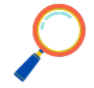

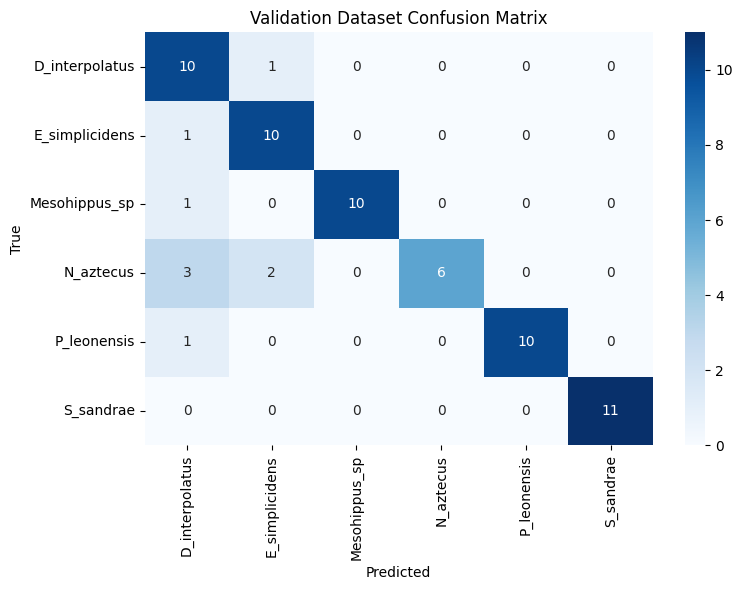

In [8]:
# Confusion Matrix for validation set
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Set model to evaluation mode
model.eval()
    
# Collect predictions and true labels
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from dataset

# Shorten class labels by removing '_resized_gray'
# Use the original class list
class_names = classes  # ["D_interpolatus", "E_simplicidens", "Mesohippus_sp", "N_aztecus", "P_leonensis"]


# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Dataset Confusion Matrix')
plt.tight_layout()
plt.show()

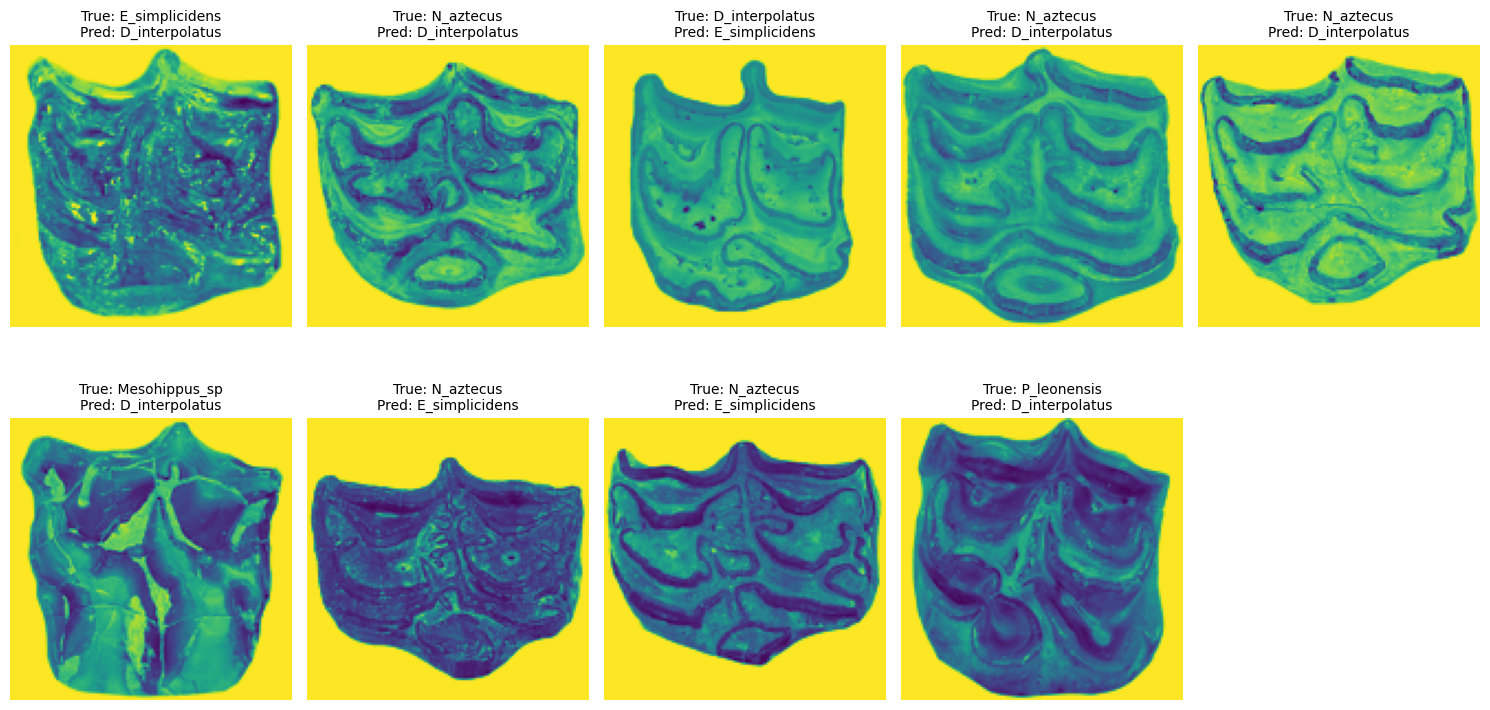

In [9]:
# Show images for mis-classifed teeth from the validation datasets

import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find misclassified indices
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_true_labels.append(labels[i].cpu().item())
                misclassified_pred_labels.append(predicted[i].cpu().item())

# Show a few misclassified images
num_to_show = min(10, len(misclassified_images))  # Show up to 10
plt.figure(figsize=(15, 8))
for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = class_names[misclassified_true_labels[idx]]
    pred_label = class_names[misclassified_pred_labels[idx]]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

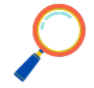

In [10]:
# Now we will test the model with unseen test data

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)  # Compute loss for this batch
        test_loss += loss.item()           # Accumulate loss

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Average loss across all batches
test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 0.5166, Test Accuracy: 86.67%


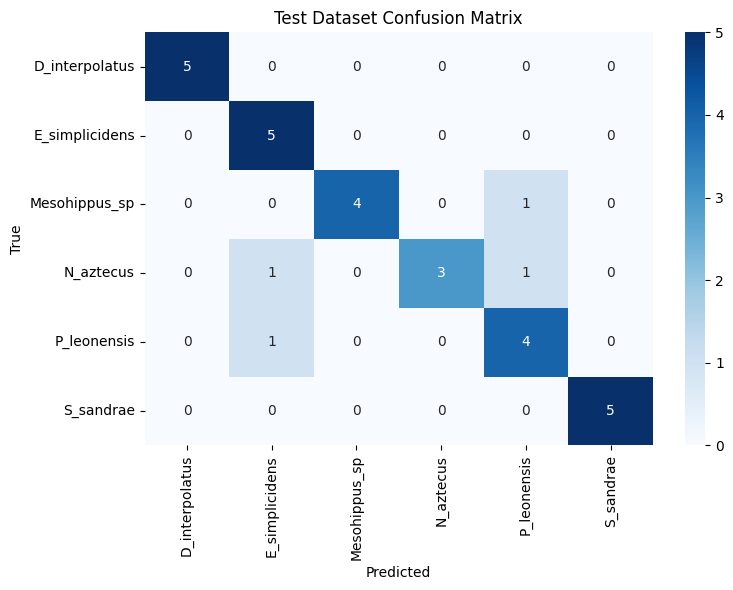

In [11]:
# Confusion Matrix for the test dataset results

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:  # Test Dataset
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        pred_labels.extend(predicted.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

# Get class names from dataset
class_names = classes  # ["D_interpolatus", "E_simplicidens", "Mesohippus_sp", "N_aztecus", "P_leonensis"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Test Dataset Confusion Matrix')
plt.tight_layout()
plt.show()

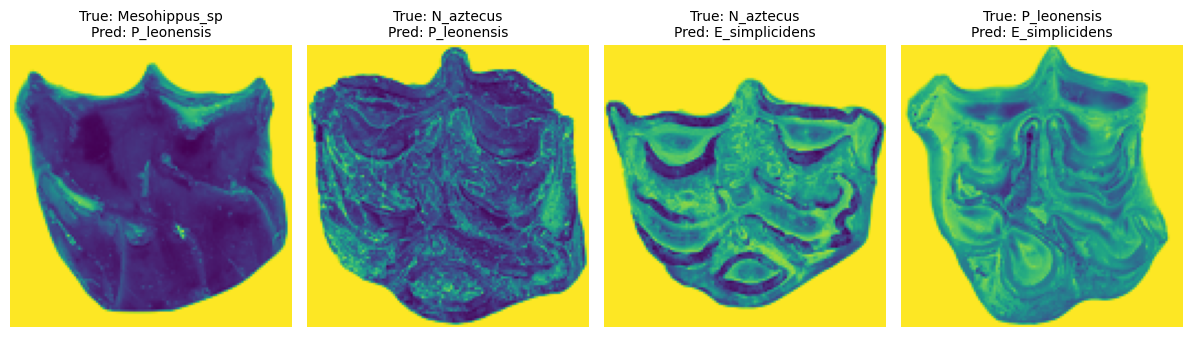

In [12]:
# Show images for mis-classifed teeth from the test datasets

import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

misclassified_images = []
misclassified_true_labels = []
misclassified_pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        # Find misclassified indices
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_true_labels.append(labels[i].cpu().item())
                misclassified_pred_labels.append(predicted[i].cpu().item())

# Show a few misclassified images
num_to_show = min(10, len(misclassified_images))  # Show up to 10
plt.figure(figsize=(15, 8))
for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = class_names[misclassified_true_labels[idx]]
    pred_label = class_names[misclassified_pred_labels[idx]]

    plt.subplot(2, 5, idx + 1)
    plt.imshow(img.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# This function shows the architecture for our SimpleCNN model

print(model)

SimpleCNN(
  (conv_layer): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


## CODE BELOW THIS POINT IS THE TESTING SPACE FOR GRAD-CAM CODE CORRECTIONS

In [14]:
# 👇 Set your trained model variable here
model_in_memory = model          

# Keep WEIGHTS_PATH_OVERRIDE unset
WEIGHTS_PATH_OVERRIDE = None

In [15]:

# =========================
# 🔧 CONFIG 
# =========================
ROOT_IMAGES_DIR        = "Image_Folder"  # parent folder with your class subfolders
INPUT_SIZE             = 128             # match your training input size
USE_GPU_IF_AVAILABLE   = False
OVERRIDE_TARGET_LAYER  = None            # e.g., "features.6" to force a layer; otherwise auto-pick last Conv2d
CHANNELS_OVERRIDE      = 1               # set 1 if trained on grayscale; 3 for RGB; None to infer

# Normalization (match training)
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB  = [0.229, 0.224, 0.225]
MEAN_GRAY = [0.5]
STD_GRAY  = [0.5]

# Background heuristics
EDGE_RATIO       = 0.12
EDGE_THRESH      = 0.55
COM_THRESH_RATIO = 0.28


# =========================
# 📦 IMPORTS & DEVICE
# =========================
import os, math, csv, time
import numpy as np
import torch, torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

device = 'cuda' if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else 'cpu'
print(f"Device: {device}")
print("CWD:", os.getcwd())

# =========================
# 🧰 UTILITIES
# =========================

def iter_resized_gray_images_only(root_dir: str):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp')
    for dirpath, _, filenames in os.walk(root_dir):
        if ".ipynb_checkpoints" in dirpath:
            continue
        # Keep only class folders that end with '_resized_gray'
        rel = os.path.relpath(dirpath, root_dir)
        cls = os.path.basename(rel)
        if not cls.endswith("_resized_gray"):
            continue
        for fname in sorted(filenames):
            if fname.lower().endswith(exts):
                yield os.path.join(dirpath, fname)

def load_image_rgb(path: str, target_hw=None) -> np.ndarray:
    img = Image.open(path)
    if img.mode == 'RGBA':
        bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img).convert('RGB')
    elif img.mode in ['LA', 'P']:
        img = img.convert('RGBA')
        bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img).convert('RGB')
    else:
        img = img.convert('RGB')
    if target_hw is not None:
        img = img.resize((target_hw[1], target_hw[0]), Image.BILINEAR)
    return (np.array(img).astype(np.float32) / 255.0)

def load_image_gray(path: str, target_hw=None) -> np.ndarray:
    img = Image.open(path).convert('L')
    if target_hw is not None:
        img = img.resize((target_hw[1], target_hw[0]), Image.BILINEAR)
    arr = np.array(img).astype(np.float32) / 255.0
    return arr[..., None]

def apply_colormap_on_image(img01: np.ndarray, heatmap01: np.ndarray, alpha=0.5) -> np.ndarray:
    cmap = plt.get_cmap('jet')
    colored_hm = cmap(np.clip(heatmap01, 0, 1))[:, :, :3]
    overlay = (1 - alpha) * img01 + alpha * colored_hm
    return np.clip(overlay, 0, 1)

def edge_mass_fraction(heatmap: np.ndarray, edge_ratio: float = EDGE_RATIO) -> float:
    H, W = heatmap.shape
    eh, ew = int(H * edge_ratio), int(W * edge_ratio)
    mask = np.zeros_like(heatmap, dtype=bool)
    mask[:eh, :] = True; mask[-eh:, :] = True; mask[:, :ew] = True; mask[:, -ew:] = True
    total = heatmap.sum() + 1e-8
    return float(heatmap[mask].sum() / total)

def center_of_mass_distance(heatmap: np.ndarray) -> float:
    H, W = heatmap.shape
    y = np.arange(H); x = np.arange(W)
    X, Y = np.meshgrid(x, y)
    mass = heatmap.sum() + 1e-8
    cx = (heatmap * X).sum() / mass
    cy = (heatmap * Y).sum() / mass
    return float(math.hypot(cx - W/2.0, cy - H/2.0))

def flag_background(edge_frac: float, com_dist: float, H: int, W: int,
                    edge_thresh: float = EDGE_THRESH, com_thresh_ratio: float = COM_THRESH_RATIO) -> bool:
    diag = math.hypot(H, W)
    return (edge_frac >= edge_thresh) or (com_dist >= com_thresh_ratio * diag)

def find_module_by_name(model: nn.Module, name: str) -> nn.Module:
    m = model
    for part in name.split('.'):
        if part.isdigit(): m = list(m.children())[int(part)]
        else: m = getattr(m, part)
    return m

def get_last_conv_layer(model: nn.Module):
    last_name, last_module = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_module = name, module
    if last_module is None:
        raise RuntimeError("No Conv2d layers found. Set OVERRIDE_TARGET_LAYER to a valid conv module path.")
    return last_name, last_module

def infer_input_channels(model: nn.Module):
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            return m.in_channels
    return 3

class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module, device: str = 'cuda'):
        self.model = model.to(device).eval()
        self.device = device
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        def fwd_hook(module, input, output):
            self.activations = output
        def bwd_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.fwd_handle = self.target_layer.register_forward_hook(fwd_hook)
        try:
            self.bwd_handle = self.target_layer.register_full_backward_hook(bwd_hook)
        except Exception:
            self.bwd_handle = self.target_layer.register_backward_hook(bwd_hook)

    def generate(self, input_tensor: torch.Tensor, target_class=None):
        input_tensor = input_tensor.to(self.device)
        logits = self.model(input_tensor)
        pred = int(logits.argmax(dim=1).item()) if target_class is None else int(target_class)
        loss = logits[:, pred].sum()
        self.model.zero_grad(set_to_none=True)
        loss.backward(retain_graph=True)

        acts = self.activations   # (B,K,H,W)
        grads = self.gradients    # (B,K,H,W)
        weights = grads.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((weights * acts).sum(dim=1, keepdim=True))
        cam_np = cam[0,0].detach().cpu().numpy()
        cam_np = cam_np - cam_np.min()
        cam_np = cam_np / (cam_np.max() + 1e-8)
        return cam_np, pred


# =========================
# 🚀 USE IN-MEMORY MODEL
# =========================
# 👇 IMPORTANT: set this to your trained model variable name
model_in_memory = model   # if your variable is named differently, change this line

# Resolve target layer
if OVERRIDE_TARGET_LAYER:
    target_layer = find_module_by_name(model_in_memory, OVERRIDE_TARGET_LAYER)
    target_layer_name = OVERRIDE_TARGET_LAYER
else:
    target_layer_name, target_layer = get_last_conv_layer(model_in_memory)

print("🎯 Target layer:", target_layer_name)

# Channels & transforms
in_channels = CHANNELS_OVERRIDE or infer_input_channels(model_in_memory)
print(f"Inferred/override input channels: {in_channels}")

if in_channels == 1:
    tfm = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN_GRAY, std=STD_GRAY),
    ])
else:
    tfm = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
    ])

# Output directories
OUT_ROOT  = "output"
CAMS_ROOT = os.path.join(OUT_ROOT, "cams")
os.makedirs(CAMS_ROOT, exist_ok=True)
CSV_PATH  = os.path.join(OUT_ROOT, "gradcam_summary.csv")
CSV_CLASS = os.path.join(OUT_ROOT, "gradcam_per_class.csv")

# Run
start = time.time()
n_images, rows = 0, []
gc = GradCAM(model_in_memory, target_layer, device=device)


for img_path in iter_resized_gray_images_only(ROOT_IMAGES_DIR):
    # Prepare model input
    pil = Image.open(img_path)
    pil = pil.convert('L') if in_channels == 1 else pil.convert('RGB')
    input_tensor = tfm(pil).unsqueeze(0)

    # Grad-CAM
    heatmap, pred = gc.generate(input_tensor)

    # Resize heatmap to INPUT_SIZE
    hm_rs = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((INPUT_SIZE, INPUT_SIZE))
    hm01 = np.array(hm_rs).astype(np.float32) / 255.0

    # Base image for overlay
    if in_channels == 1:
        base = load_image_gray(img_path, target_hw=(INPUT_SIZE, INPUT_SIZE))
        base01 = np.repeat(base, 3, axis=2)  # visualize in RGB
    else:
        base01 = load_image_rgb(img_path, target_hw=(INPUT_SIZE, INPUT_SIZE))

    overlay = apply_colormap_on_image(base01, hm01, alpha=0.5)

    # Mirror input structure in output
    rel_dir = os.path.relpath(os.path.dirname(img_path), ROOT_IMAGES_DIR)
    out_dir = os.path.join(CAMS_ROOT, rel_dir)
    os.makedirs(out_dir, exist_ok=True)
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    Image.fromarray((hm01 * 255).astype(np.uint8)).save(os.path.join(out_dir, f"{base_name}_heatmap.png"))
    Image.fromarray((overlay * 255).astype(np.uint8)).save(os.path.join(out_dir, f"{base_name}_overlay.png"))

    # Heuristics
    edge_frac = edge_mass_fraction(hm01, EDGE_RATIO)
    com_dist  = center_of_mass_distance(hm01)
    flagged   = flag_background(edge_frac, com_dist, H=INPUT_SIZE, W=INPUT_SIZE,
                                edge_thresh=EDGE_THRESH, com_thresh_ratio=COM_THRESH_RATIO)

    rows.append([img_path, pred, edge_frac, com_dist, int(flagged)])
    n_images += 1

# Write CSVs
with open(CSV_PATH, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['image_path', 'pred_class', 'edge_mass_fraction',
                'center_of_mass_distance_px', 'flagged_background'])
    w.writerows(rows)

from collections import defaultdict
agg = defaultdict(lambda: {'count':0, 'edge_sum':0.0, 'com_sum':0.0, 'flag_sum':0})
for img_path, pred, edge_frac, com_dist, flagged in rows:
    cls = os.path.basename(os.path.dirname(img_path))
    d = agg[cls]
    d['count'] += 1
    d['edge_sum'] += edge_frac
    d['com_sum']  += com_dist
    d['flag_sum'] += int(flagged)

with open(CSV_CLASS, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['class_folder', 'n_images', 'edge_mass_mean',
                'com_distance_mean_px', 'n_flagged', 'flagged_pct'])
    for cls, d in sorted(agg.items()):
        if d['count'] == 0: continue
        w.writerow([cls, d['count'], d['edge_sum']/d['count'],
                    d['com_sum']/d['count'], d['flag_sum'],
                    d['flag_sum']/d['count']])

elapsed = time.time() - start
print(f"✅ Processed {n_images} images in {elapsed:.1f}s")
print(f"📁 Overlays saved under: {CAMS_ROOT}")
print(f"📄 Per-image CSV: {CSV_PATH}")
print(f"📄 Per-class CSV: {CSV_CLASS}")

Device: cpu
CWD: /workspaces/CoC_Chapter4
🎯 Target layer: conv_layer.3
Inferred/override input channels: 1
✅ Processed 330 images in 4.4s
📁 Overlays saved under: output/cams
📄 Per-image CSV: output/gradcam_summary.csv
📄 Per-class CSV: output/gradcam_per_class.csv


In [16]:
# Triage flagged backgrounds quickly

import os, csv, shutil

CSV_IMAGE   = os.path.join("output", "gradcam_summary.csv")
OVERLAY_ROOT = os.path.join("output", "cams")
REVIEW_ROOT  = os.path.join("output", "review_flagged")
os.makedirs(REVIEW_ROOT, exist_ok=True)

copied = 0
with open(CSV_IMAGE, 'r', newline='') as f:
    r = csv.DictReader(f)
    for row in r:
        if int(row['flagged_background']) != 1:
            continue
        img_path = row['image_path']
        # Only keep resized_gray class outputs
        cls = os.path.basename(os.path.dirname(img_path))
        if not cls.endswith("_resized_gray"):
            continue

        rel_dir = os.path.relpath(os.path.dirname(img_path), "Image_Folder")
        base    = os.path.splitext(os.path.basename(img_path))[0]
        overlay_path = os.path.join(OVERLAY_ROOT, rel_dir, f"{base}_overlay.png")
        if os.path.exists(overlay_path):
            out_cls_dir = os.path.join(REVIEW_ROOT, cls)
            os.makedirs(out_cls_dir, exist_ok=True)
            shutil.copy2(overlay_path, os.path.join(out_cls_dir, f"{base}_overlay.png"))
            copied += 1

print(f"✅ Copied {copied} flagged overlays to {REVIEW_ROOT}")


✅ Copied 104 flagged overlays to output/review_flagged


Found 735 overlays


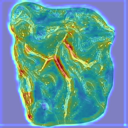

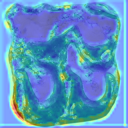

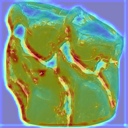

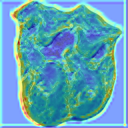

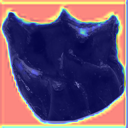

In [17]:
from IPython.display import display, HTML
from PIL import Image
import os

OVERLAY_ROOT = os.path.join("output", "cams")
BATCH_SIZE = 5  # adjust as you like

# Collect all overlay paths
overlay_paths = []
for dirpath, _, filenames in os.walk(OVERLAY_ROOT):
    for fname in sorted(filenames):
        if fname.endswith("_overlay.png"):
            overlay_paths.append(os.path.join(dirpath, fname))

print(f"Found {len(overlay_paths)} overlays")

def show_batch(start=0, batch_size=BATCH_SIZE):
    end = min(start + batch_size, len(overlay_paths))
    for p in overlay_paths[start:end]:
        display(HTML(f"<div style='font-family:monospace'>{p}</div>"))
        display(Image.open(p))
    return end

# Usage: show first batch
current = show_batch(0)

## CODE BELOW THIS POINT IS ORIGINAL GRAD-CAM CODE

In [18]:

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def grad_cam(model, input_tensor, target_layer, target_class=None):
    """
    Compute Grad-CAM for a model and a single input image (shape: [1, 1, H, W]).
    Args:
        model: nn.Module (your SimpleCNN), set to eval() before calling.
        input_tensor: torch.Tensor of shape [1, 1, H, W], normalized as your training pipeline.
        target_layer: the conv layer to hook (e.g., model.conv_layer[3]).
        target_class: int (0..num_classes-1) or None to use predicted class.
    Returns:
        cam_up: torch.Tensor of shape [H, W] with values in [0, 1]
        pred_class: int predicted class index
    """
    model.eval()
    device = next(model.parameters()).device
    input_tensor = input_tensor.to(device)

    # Storage for activations and gradients
    activations = []
    gradients = []

    # Forward hook: save feature maps
    def fwd_hook(module, inp, out):
        activations.append(out.detach())

    # Backward hook: save gradients wrt feature maps
    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    # Register hooks
    fwd_handle = target_layer.register_forward_hook(fwd_hook)
    bwd_handle = target_layer.register_backward_hook(bwd_hook)

    # Forward pass
    scores = model(input_tensor)  # shape [1, num_classes]
    pred_class = scores.argmax(dim=1).item()
    class_index = pred_class if target_class is None else target_class

    # Backward pass: gradient of selected class score w.r.t. feature maps
    model.zero_grad(set_to_none=True)
    score = scores[0, class_index]
    score.backward(retain_graph=True)

    # Get saved activations and gradients
    A = activations[-1]      # shape [1, C, H', W']
    G = gradients[-1]        # shape [1, C, H', W']

    # Global-average-pool gradients over spatial dims to get weights
    weights = G.mean(dim=(2, 3))  # shape [1, C]

    # Weighted sum of channels
    cam = (A[0] * weights[0].unsqueeze(-1).unsqueeze(-1)).sum(dim=0)  # [H', W']

    # ReLU (Grad-CAM uses positive influence only)
    cam = F.relu(cam)

    # Normalize to [0, 1]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)  # avoid divide-by-zero

    # Upsample to input size
    H, W = input_tensor.shape[-2], input_tensor.shape[-1]
    cam_up = F.interpolate(cam.unsqueeze(0).unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False)
    cam_up = cam_up.squeeze().cpu()

    # Cleanup hooks
    fwd_handle.remove()
    bwd_handle.remove()

    return cam_up, pred_class


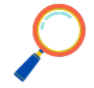

In [19]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set model to evaluation mode
model.eval()

# Use the last Conv2d layer in conv_layer
target_layer = model.conv_layer[3]  # Last convolutional layer

# Hooks to capture activations and gradients
activations = []
gradients = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

def generate_gradcam(image_tensor, class_idx):
    activations.clear()
    gradients.clear()

    # Forward pass
    output = model(image_tensor.unsqueeze(0).to(device))
    model.zero_grad()
    output[0, class_idx].backward()

    # Compute Grad-CAM
    activation = activations[0].squeeze().detach()
    gradient = gradients[0].squeeze().detach()
    weights = gradient.mean(dim=(1, 2))
    cam = torch.zeros(activation.shape[1:])
    for i, w in enumerate(weights):
        cam += w * activation[i]
    cam = cam.cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam - np.min(cam)
    cam = cam / np.max(cam)
    return cam

def crop_tooth(img_np, threshold=0.05):
    """Crop the tooth region based on intensity threshold."""
    mask = img_np.mean(axis=2) > threshold
    coords = np.argwhere(mask)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return img_np[y_min:y_max+1, x_min:x_max+1, :], (y_min, y_max, x_min, x_max)

# Visualize misclassified images
num_to_show = min(5, len(misclassified_images))
fig, axes = plt.subplots(num_to_show, 3, figsize=(12, 4 * num_to_show))

for idx in range(num_to_show):
    img = misclassified_images[idx]
    true_label = misclassified_true_labels[idx]
    pred_label = misclassified_pred_labels[idx]

    # Convert image tensor to numpy
    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # Crop tooth region
    cropped_img, (y_min, y_max, x_min, x_max) = crop_tooth(img_np)

    # Generate Grad-CAM for predicted and true classes
    heatmap_pred = generate_gradcam(img, pred_label)
    heatmap_true = generate_gradcam(img, true_label)

    # Resize heatmaps to match cropped image size
    def resize_heatmap(heatmap, target_size):
        heatmap_tensor = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0)
        return torch.nn.functional.interpolate(
            heatmap_tensor,
            size=target_size,
            mode='bilinear',
            align_corners=False
        ).squeeze().numpy()

    heatmap_pred_resized = resize_heatmap(heatmap_pred, cropped_img.shape[:2])
    heatmap_true_resized = resize_heatmap(heatmap_true, cropped_img.shape[:2])

    # Mask background inside cropped region
    mask = cropped_img.mean(axis=2) > 0.05
    heatmap_pred_masked = heatmap_pred_resized * mask
    heatmap_true_masked = heatmap_true_resized * mask

    # Column 1: Original cropped image
    axes[idx, 0].imshow(cropped_img, cmap='gray')
    axes[idx, 0].set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}", fontsize=10)
    axes[idx, 0].axis('off')

    # Column 2: Grad-CAM for predicted class
    axes[idx, 1].imshow(cropped_img, cmap='gray', alpha=0.6)
    axes[idx, 1].imshow(heatmap_pred_masked, cmap='jet', alpha=0.4)
    axes[idx, 1].set_title("Predicted Class", fontsize=10)
    axes[idx, 1].axis('off')

    # Column 3: Grad-CAM for true class
    axes[idx, 2].imshow(cropped_img, cmap='gray', alpha=0.6)
    axes[idx, 2].imshow(heatmap_true_masked, cmap='jet', alpha=0.4)
    axes[idx, 2].set_title("True Class", fontsize=10)
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

RuntimeError: Cannot use both regular backward hooks and full backward hooks on a single Module. Please use only one of them.

# Let's restart the kernel (press the ↻ button above) and choose a parameter to change and compare your model's overall accuracy. 

It is best to change only **one parameter at a time**. If you decide to try a few different changes, be sure to **restart the kernel before running any new change**. 

Below are several options you can try changing to compare your model's accuracy. 

**In the cell "Load Image Datasets" and section "Dataloaders"**
* Try changing the batch size from 32 to 16 or 64 (larger batches = faster but need more memory)

**In the cell "Define the CNN Model"**
* Try changing the kernel size from 3 to 5 (the larger kernel captures more context but also increases computational needs)
* Try adding nn.Dropout(p=0.5) after nn.MaxPool2d(2), to reduce possible overfitting

**In the cell "Initialize Model, Loss, Optimizer"**
* Try changing the learning rate from lr=0.001 to lr=0.01

**In the cell "Training Loop"**
* Try changing num_epochs = 10 to num_epochs = 20, to run more iterations of the model
